<a href="https://colab.research.google.com/github/kbfkaif04/Colab-Notebooks-/blob/main/spaceship_titanic_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spaceship Titanic — End-to-End Kaggle Solution

**Competition:** Spaceship Titanic  
**Task:** Predict whether a passenger was transported (`Transported`)  
**Metric:** Accuracy  

This notebook is designed to be **Kaggle-ready** and also runnable against the provided local CSV files. It follows a complete workflow:

1. Load and inspect the data
2. Explore missing values and target balance
3. Engineer features from passenger groups, cabins, names, and spending
4. Train a strong **CatBoost** classifier with native categorical handling
5. Evaluate using a stratified validation split
6. Inspect feature importance and validation errors
7. Retrain on all training data
8. Generate a Kaggle-compatible `submission.csv`

The competition expects one prediction per row in the test set, with the identifier and boolean `Transported` prediction.


> **Google Colab note:** Run the dependency setup cell first. It automatically installs CatBoost if the current Colab runtime does not already have it.


## Why this approach?

Spaceship Titanic mixes numeric, categorical, and partially missing data. Several fields also contain useful structure that is not explicit in the raw columns:

- `PassengerId` encodes a **travel group**.
- `Cabin` can be split into **deck, cabin number, and side**.
- `Name` gives a **surname**, which is useful as a family signal.
- The five spending columns can be combined into **total spending** and a **no-spend indicator**.

CatBoost is a good fit because it handles categorical variables directly and generally performs strongly on small/medium tabular datasets without requiring a large one-hot encoded matrix.

In [ ]:
# Colab dependency setup
# CatBoost is not included in some default Colab runtimes.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('catboost') is None:
    print('CatBoost not found. Installing it for this Colab runtime...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'catboost'])
    print('CatBoost installation complete.')
else:
    print('CatBoost is already installed.')


CatBoost is already installed.


## 1. Imports and reproducibility

In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from catboost import CatBoostClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries loaded.")

Libraries loaded.


## 2. Locate the competition files

The next cell works in both environments:

- **Kaggle:** searches under `/kaggle/input/`
- **Local / uploaded files:** searches `/mnt/data/`

This lets the same notebook be tested before uploading to Kaggle.

In [ ]:
from pathlib import Path

def find_file(filename):
    search_dirs = [
        Path("/content"),
        Path("/mnt/data"),
        Path("/kaggle/input"),
        Path.cwd(),
    ]

    matches = []
    for base_dir in search_dirs:
        if base_dir.exists():
            matches.extend(base_dir.rglob(filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename}. "
            f"Make sure the file is uploaded to Colab."
        )

    return str(matches[0])


train_path = find_file("train.csv")
test_path = find_file("test.csv")
sample_path = find_file("sample_submission.csv")

print("Train:", train_path)
print("Test:", test_path)
print("Sample submission:", sample_path)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train: /content/train.csv
Test: /content/test.csv
Sample submission: /content/sample_submission.csv
Train shape: (8693, 14)
Test shape: (4277, 13)


## 3. Load the data

In [ ]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

train.head()

Train shape: (8693, 14)
Test shape:  (4277, 13)
Sample submission shape: (4277, 2)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 4. Basic inspection

In [ ]:
display(train.info())
print("\nTarget distribution:")
display(train["Transported"].value_counts(dropna=False).rename("count").to_frame())
print("\nTarget share:")
display(train["Transported"].value_counts(normalize=True).rename("share").to_frame())

print("\nMissing values in training data:")
missing = (train.isna().mean() * 100).sort_values(ascending=False).rename("missing_pct")
display(missing.to_frame().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


None


Target distribution:


,count
Transported,
True,4378
False,4315



Target share:


,share
Transported,
True,0.503624
False,0.496376



Missing values in training data:


,missing_pct
CryoSleep,2.50
ShoppingMall,2.39
VIP,2.34
HomePlanet,2.31
Name,2.30
Cabin,2.29
VRDeck,2.16
Spa,2.11
FoodCourt,2.11
Destination,2.09


## 5. Lightweight EDA

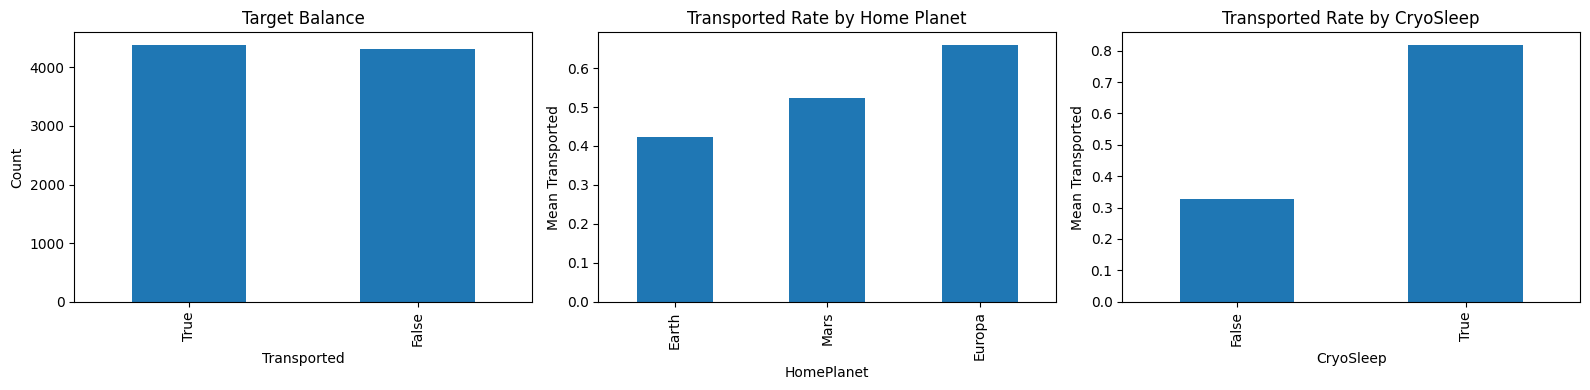

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train["Transported"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Target Balance")
axes[0].set_xlabel("Transported")
axes[0].set_ylabel("Count")

train.groupby("HomePlanet")["Transported"].mean().sort_values().plot(kind="bar", ax=axes[1])
axes[1].set_title("Transported Rate by Home Planet")
axes[1].set_ylabel("Mean Transported")

train.groupby("CryoSleep")["Transported"].mean().sort_values().plot(kind="bar", ax=axes[2])
axes[2].set_title("Transported Rate by CryoSleep")
axes[2].set_ylabel("Mean Transported")

plt.tight_layout()
plt.show()

## 6. Feature engineering

We combine train and test **only for unsupervised structure counts** such as group size and family size. No target information from the test set is used.

### Engineered features

- `GroupId`, `GroupMember`, `GroupSize`, `IsAlone` from `PassengerId`
- `Deck`, `CabinNum`, `Side` from `Cabin`
- `Surname`, `FamilySize` from `Name`
- `TotalSpend`, `NoSpend`, `SpendMissingCount` from the spending columns
- Missingness indicators for selected numeric features

In [ ]:
def engineer_features(df_all: pd.DataFrame) -> pd.DataFrame:
    df = df_all.copy()

    # -------------------------
    # Passenger / travel group
    # -------------------------
    passenger_id = df["PassengerId"].astype(str)
    pid_parts = passenger_id.str.split("_", expand=True)
    df["GroupId"] = pid_parts[0]
    df["GroupMember"] = pd.to_numeric(pid_parts[1], errors="coerce")
    df["GroupSize"] = df["GroupId"].map(df["GroupId"].value_counts())
    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)

    # -------------------------
    # Cabin structure
    # -------------------------
    cabin = df["Cabin"].fillna("Unknown/0/U").astype(str).str.split("/", expand=True)
    df["Deck"] = cabin[0]
    df["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
    df["Side"] = cabin[2]

    # -------------------------
    # Name / family
    # -------------------------
    raw_name = df["Name"].fillna("Unknown Unknown").astype(str)
    df["Surname"] = raw_name.str.rsplit(" ", n=1).str[0]
    df["FamilySize"] = df["Surname"].map(df["Surname"].value_counts())
    df.loc[df["Surname"].eq("Unknown"), "FamilySize"] = 1

    # -------------------------
    # Spending behavior
    # -------------------------
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpend"] = df[spend_cols].sum(axis=1, skipna=True)
    df["NoSpend"] = (df["TotalSpend"].fillna(0) == 0).astype(int)
    df["SpendMissingCount"] = df[spend_cols].isna().sum(axis=1)

    # -------------------------
    # Missingness indicators
    # -------------------------
    for col in ["Age", "HomePlanet", "CryoSleep", "Destination", "VIP"]:
        df[f"{col}Missing"] = df[col].isna().astype(int)

    # High-cardinality raw columns are not useful in this form.
    df = df.drop(columns=["Name", "Cabin"])

    return df

# Combine rows so group/family frequency features are computed consistently.
combined = pd.concat([train.drop(columns=["Transported"]), test], axis=0, ignore_index=True)
combined_features = engineer_features(combined)

X = combined_features.iloc[: len(train)].copy().reset_index(drop=True)
X_test = combined_features.iloc[len(train):].copy().reset_index(drop=True)
y = train["Transported"].astype(int).reset_index(drop=True)

print("Engineered train shape:", X.shape)
print("Engineered test shape:", X_test.shape)
display(X.head())

Engineered train shape: (8693, 28)
Engineered test shape: (4277, 28)


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupId,GroupMember,GroupSize,IsAlone,Deck,CabinNum,Side,Surname,FamilySize,TotalSpend,NoSpend,SpendMissingCount,AgeMissing,HomePlanetMissing,CryoSleepMissing,DestinationMissing,VIPMissing
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,1,1,1,B,0,P,Maham,5,0.0,1,0,0,0,0,0,0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,1,1,1,F,0,S,Juanna,6,736.0,0,0,0,0,0,0,0
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,1,2,0,A,0,S,Altark,1,10383.0,0,0,0,0,0,0,0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,2,2,0,A,0,S,Solam,5,5176.0,0,0,0,0,0,0,0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,1,1,1,F,1,S,Willy,11,1091.0,0,0,0,0,0,0,0


## 7. Prepare categorical columns

CatBoost expects categorical features to be strings. Missing categorical values are therefore represented by the explicit category `Missing`.

In [ ]:
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_features:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)

print("Categorical features:")
print(categorical_features)

Categorical features:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'GroupId', 'Deck', 'Side', 'Surname']


## 8. Train/validation split

A stratified holdout keeps the `Transported` class proportions similar between training and validation sets. The validation set is used only for model selection and early stopping.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Validation target rate:", round(y_valid.mean(), 4))

Training rows: 6954
Validation rows: 1739
Validation target rate: 0.5037


## 9. CatBoost model

In [ ]:
model = CatBoostClassifier(
    iterations=1500,
    depth=7,
    learning_rate=0.045,
    loss_function="Logloss",
    eval_metric="Accuracy",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=SEED,
    verbose=100,
    allow_writing_files=False,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=120,
)

print("Best iteration:", model.get_best_iteration())

0:	learn: 0.7556802	test: 0.7412306	best: 0.7412306 (0)	total: 454ms	remaining: 11m 20s
100:	learn: 0.8185217	test: 0.7993099	best: 0.7998850 (98)	total: 11.2s	remaining: 2m 35s
200:	learn: 0.8405234	test: 0.8027602	best: 0.8056354 (178)	total: 20.8s	remaining: 2m 14s
300:	learn: 0.8576359	test: 0.8039103	best: 0.8108108 (245)	total: 26.1s	remaining: 1m 43s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.8108108108
bestIteration = 245

Shrink model to first 246 iterations.
Best iteration: 245


## 10. Validation performance

Validation accuracy: 0.8108

Classification report:
                 precision    recall  f1-score   support

Not transported       0.81      0.81      0.81       863
    Transported       0.81      0.81      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



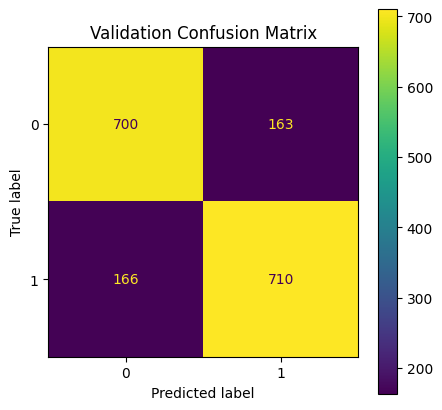

In [ ]:
valid_proba = model.predict_proba(X_valid)[:, 1]
valid_pred = (valid_proba >= 0.50).astype(int)

accuracy = accuracy_score(y_valid, valid_pred)
print(f"Validation accuracy: {accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_valid, valid_pred, target_names=["Not transported", "Transported"]))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_valid, valid_pred, ax=ax)
ax.set_title("Validation Confusion Matrix")
plt.show()

## 11. Feature importance

,importance
Spa,13.507930
VRDeck,10.203002
Deck,9.925724
HomePlanet,8.761826
FoodCourt,8.348071
CabinNum,8.303239
RoomService,7.676271
CryoSleep,6.779236
Side,6.464707
TotalSpend,4.493719


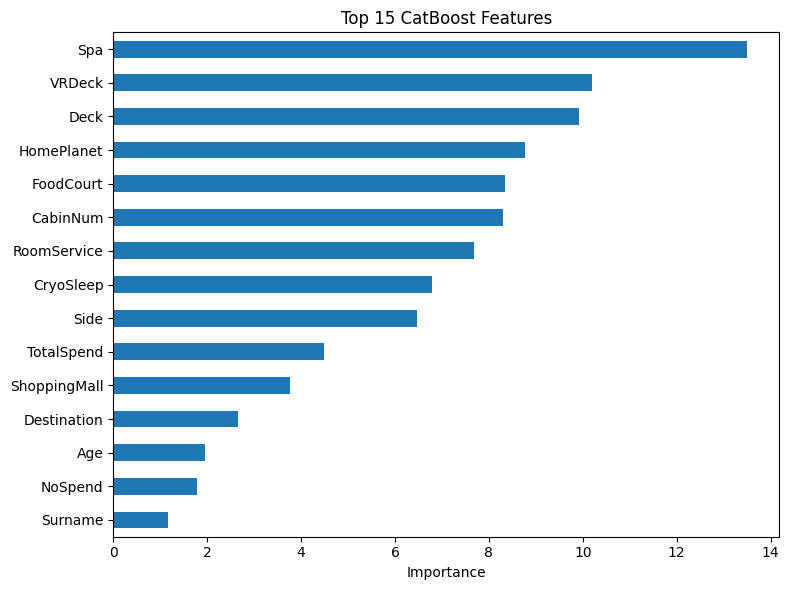

In [ ]:
importance = pd.Series(
    model.get_feature_importance(),
    index=X.columns,
).sort_values(ascending=False)

display(importance.head(20).to_frame("importance"))

importance.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 CatBoost Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Validation error inspection

Looking at misclassified examples is useful for understanding where the model is uncertain and can guide further feature engineering.

In [ ]:
errors = X_valid.copy()
errors["Actual"] = y_valid.to_numpy()
errors["Predicted"] = valid_pred
errors["ProbabilityTransported"] = valid_proba
errors["Correct"] = errors["Actual"] == errors["Predicted"]

misclassified = errors.loc[~errors["Correct"]].copy()
print("Misclassified validation rows:", len(misclassified))
display(
    misclassified.sort_values("ProbabilityTransported").head(15)
)

Misclassified validation rows: 329


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupId,GroupMember,GroupSize,IsAlone,Deck,CabinNum,Side,Surname,FamilySize,TotalSpend,NoSpend,SpendMissingCount,AgeMissing,HomePlanetMissing,CryoSleepMissing,DestinationMissing,VIPMissing,Actual,Predicted,ProbabilityTransported,Correct
3867,4147_01,Europa,False,TRAPPIST-1e,54.0,False,0.0,NaN,0.0,3200.0,0.0,4147,1,2,0,C,149,S,Caphact,3,3200.0,0,1,0,0,0,0,0,1,0,0.045060,False
2091,2237_01,Europa,False,55 Cancri e,28.0,False,0.0,162.0,741.0,3733.0,99.0,2237,1,2,0,C,83,S,Skatik,4,4735.0,0,0,0,0,0,0,0,1,0,0.084642,False
7951,8492_01,Earth,False,TRAPPIST-1e,28.0,False,0.0,62.0,3.0,667.0,0.0,8492,1,1,1,F,1740,P,Lis,11,732.0,0,0,0,0,0,0,0,1,0,0.088049,False
2679,2870_01,Earth,False,TRAPPIST-1e,59.0,False,0.0,0.0,1.0,920.0,1.0,2870,1,1,1,G,454,S,Nancey,7,922.0,0,0,0,0,0,0,0,1,0,0.092067,False
2875,3110_01,Earth,False,TRAPPIST-1e,24.0,False,520.0,0.0,0.0,195.0,0.0,3110,1,1,1,G,509,P,Dandra,12,715.0,0,0,0,0,0,0,0,1,0,0.093124,False
4059,4336_04,Europa,False,55 Cancri e,40.0,False,2320.0,0.0,4874.0,3131.0,498.0,4336,4,4,0,C,155,S,Krazet,4,10823.0,0,0,0,0,0,0,0,1,0,0.099919,False
3901,4176_03,Mars,False,TRAPPIST-1e,20.0,False,760.0,0.0,742.0,352.0,0.0,4176,3,7,0,F,859,P,Shood,4,1854.0,0,0,0,0,0,0,0,1,0,0.101265,False
2456,2635_01,Mars,False,TRAPPIST-1e,18.0,False,1867.0,0.0,29.0,72.0,NaN,2635,1,1,1,D,78,P,Oafron,7,1968.0,0,1,0,0,0,0,0,1,0,0.103098,False
5866,6213_01,Earth,False,55 Cancri e,25.0,Missing,258.0,0.0,306.0,311.0,24.0,6213,1,1,1,F,1280,P,Edgary,7,899.0,0,0,0,0,0,0,1,1,0,0.106706,False
8268,8828_01,Earth,False,55 Cancri e,19.0,Missing,0.0,6.0,0.0,0.0,1179.0,8828,1,1,1,F,1711,S,Charly,10,1185.0,0,0,0,0,0,0,1,1,0,0.107506,False


## 13. Retrain on all available training data

After validation identifies a useful number of boosting rounds, retrain using all labeled examples. This gives the final model access to every training row before predicting the test set.

In [ ]:
best_iteration = model.get_best_iteration()

# CatBoost iteration indices are zero-based, so add 1 for the count of trees.
final_iterations = max(100, best_iteration + 1)

final_model = CatBoostClassifier(
    iterations=final_iterations,
    depth=7,
    learning_rate=0.045,
    loss_function="Logloss",
    l2_leaf_reg=5,
    random_strength=1,
    random_seed=SEED,
    verbose=200,
    allow_writing_files=False,
)

final_model.fit(
    X,
    y,
    cat_features=categorical_features,
)

print("Final number of trees:", final_iterations)

0:	learn: 0.6700991	total: 37ms	remaining: 9.06s
200:	learn: 0.3567218	total: 7.11s	remaining: 1.59s
245:	learn: 0.3439747	total: 9.06s	remaining: 0us
Final number of trees: 246


## 14. Predict the test set and build the submission

The provided sample submission is used as the template so the identifier column and row order stay aligned with the competition format.

In [ ]:
# The final trained model already produced predictions for X_test
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = test_proba >= 0.50

# Build submission using the provided sample_submission format
submission = sample_submission.copy()
submission["Transported"] = test_pred.astype(bool)

# Safety checks
assert len(submission) == len(test), "Submission row count does not match test set."
assert submission.columns.tolist() == sample_submission.columns.tolist(), \
    "Submission columns do not match sample submission."
assert submission["PassengerId"].tolist() == sample_submission["PassengerId"].tolist(), \
    "PassengerId order changed."

# Save in Google Colab
submission_path = Path("/content/submission.csv")
submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
print("Submission shape:", submission.shape)

display(submission.head(10))

Submission saved to: /content/submission.csv
Submission shape: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,False


## 15. Final sanity checks

In [ ]:
print("Submission shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print("Positive predictions:", int(submission["Transported"].sum()))
print("Negative predictions:", int((~submission["Transported"]).sum()))

print("\nFirst 5 submission rows:")
display(submission.head())

Submission shape: (4277, 2)
Columns: ['PassengerId', 'Transported']
Positive predictions: 2189
Negative predictions: 2088

First 5 submission rows:


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 16. How to use this on Kaggle

1. Open the **Spaceship Titanic** competition and create a new notebook.
2. Add the competition dataset as notebook input.
3. Paste or upload this notebook.
4. Run all cells.
5. The final cell creates `submission.csv` under `/kaggle/working/`.
6. In Kaggle, use the notebook output/submission workflow to submit the file.

### Practical improvement ideas

For additional experimentation, the next things worth trying are:

- 5-fold cross-validation and ensembling.
- A second tabular model such as LightGBM/XGBoost and probability averaging.
- More interaction features, especially `CryoSleep × spending`, `Deck × Side`, and age bands.
- Carefully validated family/group prediction rules using **only labels available at inference time**.

The important constraint is to avoid using the hidden test target or any feature constructed from test labels. That would make the local score look better while harming the validity of the competition solution.